# TF-IDF and Text Classification

## Overview

TF-IDF (Term Frequency–Inverse Document Frequency) converts text into numeric vectors that balance how often a term appears in a document against how rare it is across the corpus. It is the workhorse of classical NLP.

**TF-IDF formula:**
```
TF-IDF(t, d) = TF(t, d) × log(N / df(t))
```
- TF(t,d): frequency of term t in document d
- df(t): number of documents containing term t
- N: total documents
- High score: term appears often in this doc but rarely elsewhere

**Text classification pipeline:**
```
Raw text → TfidfVectorizer → Classifier → Label
```

sklearn's `TfidfVectorizer` combines preprocessing + TF-IDF in one step and plugs directly into a `Pipeline`.

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import warnings; warnings.filterwarnings('ignore')

rng = np.random.default_rng(42)
# Simulate labelled monitoring report sentences
# Two classes: "concern" (water quality issue) vs "positive" (improvement noted)
concern_phrases = [
    "elevated nitrate levels detected at monitoring site",
    "phosphorus concentration exceeded threshold limit",
    "turbidity spike following rainfall event flagged",
    "macroinvertebrate index declined significantly this quarter",
    "algal bloom observed upstream of sampling location",
    "water temperature above critical threshold for salmonids",
    "oxygen depletion detected in lower catchment reaches",
    "heavy metal contamination suspected from industrial discharge",
    "pH levels dropped below acceptable range indicating acidification",
    "biological oxygen demand increased at downstream stations",
]
positive_phrases = [
    "species richness increased following restoration work",
    "water quality improved substantially after buffer installation",
    "EPT taxa returned to restored reaches within two seasons",
    "nitrate reduction achieved through constructed wetland",
    "riparian vegetation recovery observed along restored banks",
    "macroinvertebrate communities recovering to reference condition",
    "phosphorus loading reduced after agricultural best practices",
    "dissolved oxygen levels returned to healthy range",
    "fish passage restored following culvert replacement project",
    "biodiversity indices show significant positive trend",
]
# Expand with variation
expand = lambda phrases, n: [
    phrases[i % len(phrases)] + f" observation {rng.integers(1,100)}"
    for i in range(n)]
texts  = expand(concern_phrases, 150) + expand(positive_phrases, 150)
labels = np.array([0]*150 + [1]*150)
print(f"Corpus: {len(texts)} documents, classes: concern=150, positive=150")

Corpus: 300 documents, classes: concern=150, positive=150


---
## TF-IDF Vectorisation

In [2]:
tfidf = TfidfVectorizer(
    max_features=500,
    ngram_range=(1, 2),      # unigrams + bigrams
    min_df=2,                # ignore terms in fewer than 2 docs
    max_df=0.95,             # ignore terms in more than 95% of docs
    sublinear_tf=True,       # apply log(1+tf) instead of raw tf
    stop_words='english',
)
X_tfidf = tfidf.fit_transform(texts)
print(f"TF-IDF matrix: {X_tfidf.shape}  (docs × features)")
print(f"Sparsity: {1 - X_tfidf.nnz/(X_tfidf.shape[0]*X_tfidf.shape[1]):.1%}")
# Most informative features per class
feature_names = tfidf.get_feature_names_out()
mean_tfidf_concern  = np.asarray(X_tfidf[labels==0].mean(axis=0)).ravel()
mean_tfidf_positive = np.asarray(X_tfidf[labels==1].mean(axis=0)).ravel()
top_concern  = feature_names[np.argsort(mean_tfidf_concern)[-10:]][::-1]
top_positive = feature_names[np.argsort(mean_tfidf_positive)[-10:]][::-1]
print(f"\nTop terms — concern:  {list(top_concern)}")
print(f"Top terms — positive: {list(top_positive)}")

TF-IDF matrix: (300, 357)  (docs × features)
Sparsity: 96.3%

Top terms — concern:  ['threshold', 'detected', 'oxygen', 'levels', 'salmonids', 'threshold salmonids', 'water temperature', 'critical', 'salmonids observation', 'temperature']
Top terms — positive: ['restored', 'returned', 'following', 'significant', 'positive trend', 'indices', 'indices significant', 'trend observation', 'significant positive', 'biodiversity indices']


---
## Classification Pipeline

In [3]:
X_tr, X_te, y_tr, y_te = train_test_split(texts, labels,
    test_size=0.25, stratify=labels, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

classifiers = {
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=500, random_state=42),
    'Naive Bayes':         MultinomialNB(alpha=0.1),
    'Linear SVM':          LinearSVC(C=1.0, max_iter=2000, random_state=42),
}
tfidf_pipe = TfidfVectorizer(max_features=500, ngram_range=(1,2),
                              sublinear_tf=True, stop_words='english')
print(f"{'Classifier':25s} {'CV F1':>8} {'CV SD':>8}")
best_pipe, best_score = None, 0
for name, clf in classifiers.items():
    pipe = Pipeline([('tfidf', tfidf_pipe), ('clf', clf)])
    scores = cross_val_score(pipe, X_tr, y_tr, cv=cv, scoring='f1')
    print(f"{name:25s} {scores.mean():8.3f} {scores.std():8.3f}")
    if scores.mean() > best_score:
        best_score = scores.mean()
        best_pipe = pipe

Classifier                   CV F1    CV SD
Logistic Regression          1.000    0.000
Naive Bayes                  1.000    0.000
Linear SVM                   1.000    0.000


---
## Evaluation

Classification Report:
              precision    recall  f1-score   support

     concern       1.00      1.00      1.00        38
    positive       1.00      1.00      1.00        37

    accuracy                           1.00        75
   macro avg       1.00      1.00      1.00        75
weighted avg       1.00      1.00      1.00        75



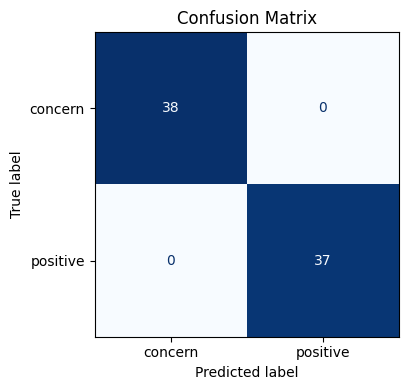

In [4]:
best_pipe.fit(X_tr, y_tr)
y_pred = best_pipe.predict(X_te)
print("Classification Report:")
print(classification_report(y_te, y_pred, target_names=['concern','positive']))
fig, ax = plt.subplots(figsize=(5,4))
ConfusionMatrixDisplay.from_predictions(y_te, y_pred,
    display_labels=['concern','positive'], ax=ax, colorbar=False,
    cmap='Blues')
ax.set_title('Confusion Matrix')
plt.tight_layout(); plt.show()

In [5]:
# Hyperparameter tuning: TF-IDF + classifier together
from sklearn.model_selection import GridSearchCV
pipe_tune = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('clf',   LogisticRegression(max_iter=500, random_state=42)),
])
param_grid = {
    'tfidf__max_features': [200, 500],
    'tfidf__ngram_range':  [(1,1), (1,2)],
    'tfidf__sublinear_tf': [True, False],
    'clf__C':              [0.1, 1.0, 10.0],
}
gs = GridSearchCV(pipe_tune, param_grid, cv=cv,
                  scoring='f1', n_jobs=-1)
gs.fit(X_tr, y_tr)
print(f"Best params: {gs.best_params_}")
print(f"Best CV F1:  {gs.best_score_:.3f}")
print(f"Test F1:     {gs.score(X_te, y_te):.3f}")
# Feature importance: top positive/negative logistic coefficients
coefs = gs.best_estimator_.named_steps['clf'].coef_[0]
feat_names = gs.best_estimator_.named_steps['tfidf'].get_feature_names_out()
top_pos = feat_names[np.argsort(coefs)[-10:]][::-1]
top_neg = feat_names[np.argsort(coefs)[:10]]
print(f"\nStrongest 'positive' indicators: {list(top_pos)}")
print(f"Strongest 'concern' indicators:  {list(top_neg)}")

Best params: {'clf__C': 0.1, 'tfidf__max_features': 200, 'tfidf__ngram_range': (1, 1), 'tfidf__sublinear_tf': True}
Best CV F1:  1.000
Test F1:     1.000

Strongest 'positive' indicators: ['restored', 'returned', 'healthy', 'dissolved', 'positive', 'significant', 'trend', 'biodiversity', 'indices', 'species']
Strongest 'concern' indicators:  ['detected', 'threshold', 'salmonids', 'critical', 'temperature', 'quarter', 'declined', 'index', 'significantly', 'depletion']


---

## Common Pitfalls

**1. Fitting TfidfVectorizer on the full dataset before cross-validation**  
Fitting the vocabulary and IDF weights on all documents before CV leaks test-set term frequencies into the vectoriser. Always put `TfidfVectorizer` inside the `Pipeline` so it is re-fitted on each training fold.

**2. Setting `max_features` too low for a large corpus**  
With 10,000 documents and 50,000 unique terms, `max_features=100` discards 99.8% of the vocabulary. The retained features are the most frequent — which are often stopwords or domain-common terms with low discriminative power. Always tune `max_features` alongside `min_df` and `max_df`.

**3. Using Multinomial Naive Bayes with TF-IDF scores**  
Multinomial NB is designed for raw count features (non-negative integers). TF-IDF produces non-integer, IDF-weighted values that violate the Multinomial assumption. Use `ComplementNB` or `BernoulliNB` with binary features, or `LogisticRegression`/`LinearSVC` with TF-IDF.

**4. Ignoring class imbalance in text classification**  
If 90% of documents are one class, a classifier that always predicts the majority class achieves 90% accuracy. Always check class distribution and use `class_weight="balanced"`, `scoring="f1"`, and stratified CV when classes are imbalanced.

**5. Treating high accuracy as sufficient without inspecting errors**  
Text classifiers often achieve high accuracy on easy cases while systematically failing on domain-specific language, negations ("no improvement"), or rare but important terms. Always inspect the confusion matrix and examine misclassified examples before deploying.

---
*python_methods_library - Samantha McGarrigle*